# Energy Model Comparison — New Labels

**Selection table source:** `outputs/model_comparison/selection_table.csv`
**Labels:** `data/meta/triple_barrier_labels.csv` (new triple-barrier labels)

| Instrument | Group | Champion | AUC | lower CI | Signal |
|-----------|-------|---------|-----|----------|--------|
| cl1s | cl1s | Logistic | 0.537 | 0.488 | ✗ NO SIGNAL |
| ho1s | energy_cl_ho | MLP | 0.492 | 0.303 | ✗ NO SIGNAL |
| rb1s | rb1s | Logistic | 0.577 | 0.506 | ✓ SIGNAL |
| ng1s | energy_all | MLP | 0.658 | 0.519 | ✓ SIGNAL |

> **cl1s / rb1s** — individual logistic models.
> **ho1s** — pooled `energy_cl_ho` MLP: trained on all 321 energy_cl_ho rows; scored on
> ho1s's CPCV slice (Phase 1) or ho1s's sealed-test slice (Phase 2).
> **ng1s** — pooled `energy_all` MLP: trained on all 773 energy_all rows; scored on
> ng1s's CPCV slice (Phase 1) or ng1s's sealed-test slice (Phase 2).

**MLP hyperparameters locked from champion run (not retuned per variant):**
- energy_cl_ho: hidden=(64,), alpha=0.01, StandardScaler per fold
- energy_all:   hidden=(64,), alpha=0.01, StandardScaler per fold

**Lock rule:** simplest variant within **1 cross-path std** of full.
**Train / test split:** global cut 2021-10-06; embargo end 2021-10-20.
**Test scored once** after the lock is committed.

> ⚠️ **cl1s and ho1s are NO SIGNAL** — included for completeness only.
> **rb1s and ng1s are marginal signals** (lower CI 0.51 / 0.52). Watch whether the
> reduced sets hold within 1σ of full, and treat ng1s's thin-slice signal cautiously
> (28 train rows in the energy_all pool).

---


In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

_HERE = Path().resolve()
while _HERE.name != "new_work" and _HERE != _HERE.parent:
    _HERE = _HERE.parent
assert _HERE.name == "new_work", "Could not locate new_work directory"

ENERGY_OUT = _HERE / "outputs" / "model_comparison" / "energy"
SEL_TABLE  = _HERE / "outputs" / "model_comparison" / "selection_table.csv"

sel     = pd.read_csv(SEL_TABLE, index_col="instrument")
cpcv_df = pd.read_csv(ENERGY_OUT / "cpcv_results.csv")
lock_df = pd.read_csv(ENERGY_OUT / "locked_picks.csv")
oos_df  = pd.read_csv(ENERGY_OUT / "oos_results.csv")

locked = dict(zip(lock_df["inst"], lock_df["locked_variant"]))

SIMPLICITY = {
    "cl1s": ["reduced", "pruned", "full"],
    "ho1s": ["reduced", "pruned", "full"],
    "rb1s": ["reduced_min", "reduced", "pruned", "full"],
    "ng1s": ["reduced", "pruned", "full"],
}
INSTS = ["cl1s", "ho1s", "rb1s", "ng1s"]

def fmt(v, d=4):
    return "—" if pd.isna(v) else f"{v:.{d}f}"

print(f"CPCV rows: {len(cpcv_df)}  |  OOS rows: {len(oos_df)}")
print(f"Locked picks: {locked}")


CPCV rows: 13  |  OOS rows: 13
Locked picks: {'cl1s': 'reduced', 'ho1s': 'reduced', 'rb1s': 'reduced_min', 'ng1s': 'reduced'}


## Variant Definitions

### cl1s — cl1s / logistic | NO SIGNAL (exploratory)
| Variant | Feature set | Rationale |
|---------|------------|-----------|
| **full** | All 101 cl1s features | Baseline |
| **pruned** | C2_f11_lowfreq_macro + C14_f12 | The two significant clusters from importance |
| **reduced** | PC1(C2_f11_lowfreq_macro) + PC1(C14_f12) + f11_crude_stock_surprise + f2_vol_10 + f11_china_pmi_level | PCA per fold on each sig cluster; 3 raw macro add-ons |

PCA discipline: `StandardScaler` + `PCA(n_components=1)` fitted on training rows per CPCV fold,
applied to test. f2_vol_10 and f11_china_pmi_level are SHAP add-ons from non-significant clusters.

### ho1s — energy_cl_ho / MLP | NO SIGNAL (exploratory)
| Variant | Feature set | Rationale |
|---------|------------|-----------|
| **full** | All 101 energy_cl_ho features | Baseline |
| **pruned** | C8_f11_lowfreq_macro + C15_f11 + C1_f1 | Top-3 clusters by raw MDA |
| **reduced** | f11_vix_term_slope + f4_pc3 + f1_bb_bandwidth_20 + f11_vix_5d_change | 4 raw features; f4_pc3 is the pre-computed frozen F4 latent — used as-is |

### rb1s — rb1s / logistic | SIGNAL (marginal, lower CI 0.51)
| Variant | Feature set | Rationale |
|---------|------------|-----------|
| **full** | All 101 rb1s features | Baseline |
| **pruned** | F5_signal + C6_f11_lowfreq_macro + C1_f1 | Top-3 clusters by raw MDA |
| **reduced** | f5_signal + f11_hy_oas_5d_change + f11_dist_stock_surprise + f2_vol_ratio_20_60 | 4 raw: primary signal + HY spread + stock surprise + vol ratio |
| **reduced_min** | f5_signal + f11_hy_oas_5d_change | 2 features only — tests whether rb1s's signal is essentially just re-reading f5_signal + HY spread |

> rb1s has **no individually significant** clusters in the importance analysis. All four
> variants are exploratory simplifications for regularisation.

### ng1s — energy_all / MLP | SIGNAL (marginal, lower CI 0.52)
| Variant | Feature set | Rationale |
|---------|------------|-----------|
| **full** | All 104 energy_all features | Baseline |
| **pruned** | C15_f7 | The **one significant** cluster: OI-level features |
| **reduced** | f7_oi_change + f7_oi_level + f2_atr_14 + hmm_vol_next_turbulent + hmm_vol_p2_turbulent + hmm_vol_p0_calm | SHAP reps proposed via RF importance heuristic; validated here on the MLP |

> **ng1s NOTE:** The reduced features were selected via RF importance (a surrogate for the MLP
> champion). This analysis validates those features **directly on the MLP champion**, not on the
> surrogate. `inst_rb1s` is deliberately excluded — it is constant (= 0) on the ng1s pool slice.

---


---
## Phase 1 — CPCV Variant Scoring (Train Only)

In [2]:
# ── Phase 1: CPCV summary table ───────────────────────────────────────────────
print("Phase 1 — CPCV variant scoring (TRAIN only)")
print("Lock rule: simplest variant within 1 cross-path std of full\n")

rows = []
for inst in INSTS:
    sub   = cpcv_df[cpcv_df["inst"] == inst]
    full  = sub[sub["variant"] == "full"].iloc[0]
    thresh = float(full["auc_mean"]) - float(full["auc_std"])
    for v in SIMPLICITY[inst]:
        r = sub[sub["variant"] == v]
        if r.empty:
            continue
        r = r.iloc[0]
        rows.append({
            "Inst":      inst,
            "Variant":   v,
            "AUC mean":  round(float(r["auc_mean"]), 4),
            "AUC std":   round(float(r["auc_std"]),  4),
            "Log-loss":  round(float(r["logloss"]),   4) if not pd.isna(r["logloss"]) else float("nan"),
            "Brier":     round(float(r["brier"]),     4) if not pd.isna(r["brier"])   else float("nan"),
            "n paths":   int(r["n_paths"]),
            "Threshold": round(thresh, 4),
            "LOCKED":    "← LOCKED" if locked.get(inst) == v else "",
        })

phase1_df = pd.DataFrame(rows)
display(
    phase1_df.style
    .format({"AUC mean": "{:.4f}", "AUC std": "{:.4f}",
             "Log-loss": "{:.4f}", "Brier": "{:.4f}", "Threshold": "{:.4f}"})
    .apply(lambda col: ["background-color: #e3f2fd" if v == "← LOCKED" else ""
                        for v in phase1_df["LOCKED"]], axis=0)
    .set_caption("Phase 1 CPCV — all variants (train only; ho1s/ng1s: 12/15 usable paths due to thin slices)")
)


Phase 1 — CPCV variant scoring (TRAIN only)
Lock rule: simplest variant within 1 cross-path std of full



,Inst,Variant,AUC mean,AUC std,Log-loss,Brier,n paths,Threshold,LOCKED
0,cl1s,reduced,0.5842,0.0224,0.7014,0.2471,15,0.4901,← LOCKED
1,cl1s,pruned,0.5761,0.0233,0.6830,0.2451,15,0.4901,
2,cl1s,full,0.5399,0.0498,1.3803,0.2811,15,0.4901,
3,ho1s,reduced,0.6589,0.1846,0.6487,0.2294,12,0.3292,← LOCKED
4,ho1s,pruned,0.4850,0.2125,0.6677,0.2387,12,0.3292,
5,ho1s,full,0.5207,0.1914,1.0075,0.3182,12,0.3292,
6,rb1s,reduced_min,0.7215,0.0695,0.6737,0.2377,15,0.4828,← LOCKED
7,rb1s,reduced,0.6954,0.0618,0.6850,0.2389,15,0.4828,
8,rb1s,pruned,0.6286,0.1085,0.7229,0.2513,15,0.4828,
9,rb1s,full,0.5538,0.0710,0.9500,0.2568,15,0.4828,


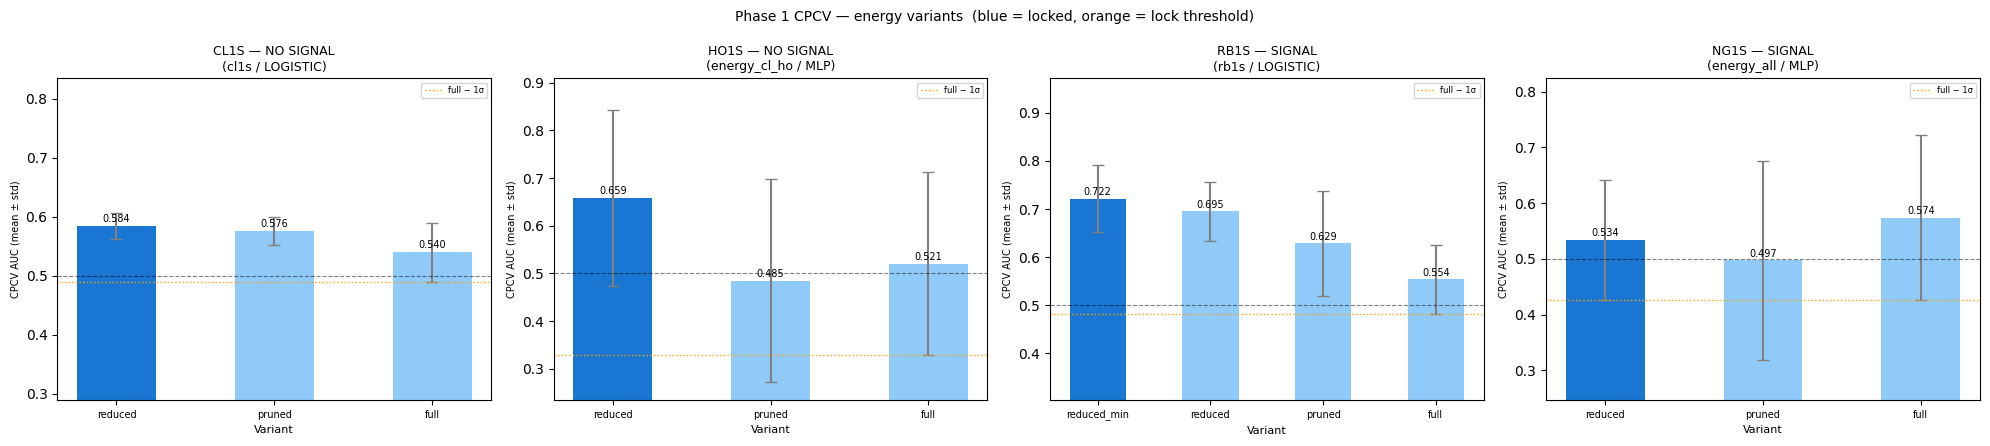

In [3]:
# ── Phase 1 CPCV bar charts ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, inst in zip(axes, INSTS):
    simp = SIMPLICITY[inst]
    sub  = cpcv_df[cpcv_df["inst"] == inst].set_index("variant")
    variants = simp  # simplest → most complex
    means  = [float(sub.loc[v, "auc_mean"]) if v in sub.index else float("nan") for v in variants]
    stds   = [float(sub.loc[v, "auc_std"])  if v in sub.index else 0.0          for v in variants]
    colors = ["#1976D2" if v == locked.get(inst) else "#90CAF9" for v in variants]

    ax.bar(variants, means, yerr=stds, color=colors,
           error_kw={"ecolor": "grey", "capsize": 4}, width=0.5)
    ax.axhline(0.5, color="black", linestyle="--", lw=0.8, alpha=0.5)
    full_m  = float(sub.loc["full", "auc_mean"]) if "full" in sub.index else float("nan")
    full_sd = float(sub.loc["full", "auc_std"])  if "full" in sub.index else float("nan")
    ax.axhline(full_m - full_sd, color="orange", linestyle=":", lw=1.0, label="full − 1σ")

    valid = [m for m in means if not np.isnan(m)]
    lo = max(0.2, min(valid) - 0.25) if valid else 0.2
    hi = min(1.0, max(valid) + 0.25) if valid else 1.0
    ax.set_ylim(lo, hi)

    s = sel.loc[inst]
    sig_lbl = "SIGNAL" if s["signal"] else "NO SIGNAL"
    ax.set_title(f"{inst.upper()} — {sig_lbl}\n({s['best_group']} / {s['best_model'].upper()})", fontsize=9)
    ax.set_xlabel("Variant", fontsize=8)
    ax.set_ylabel("CPCV AUC (mean ± std)", fontsize=7)
    ax.tick_params(axis="x", labelsize=7)
    for bar, m in zip(ax.patches, means):
        if not np.isnan(m):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                    f"{m:.3f}", ha="center", va="bottom", fontsize=7)
    ax.legend(fontsize=6)

plt.suptitle("Phase 1 CPCV — energy variants  (blue = locked, orange = lock threshold)",
             fontsize=10)
plt.tight_layout()
plt.show()


---
## Locked Picks (Committed Before Phase 2)

In [4]:
# ── Locked picks (committed before Phase 2) ───────────────────────────────────
print("=" * 64)
print("LOCKED PICKS — committed before Phase 2 / sealed test")
print("=" * 64)
for inst in INSTS:
    s     = sel.loc[inst]
    lv    = locked[inst]
    sub   = cpcv_df[cpcv_df["inst"] == inst].set_index("variant")
    full  = sub.loc["full"]
    lrow  = sub.loc[lv]
    thresh = float(full["auc_mean"]) - float(full["auc_std"])
    sig    = "SIGNAL" if s["signal"] else "NO SIGNAL"
    pool   = s["best_group"]
    model  = s["best_model"].upper()
    n_paths = int(lrow["n_paths"])
    print(f"\n  {inst.upper()} ({sig}) — {pool} / {model} — locked: {lv}")
    print(f"    full AUC={full['auc_mean']:.4f} ± {full['auc_std']:.4f}  threshold={thresh:.4f}")
    print(f"    {lv} AUC={lrow['auc_mean']:.4f} ± {lrow['auc_std']:.4f}  "
          f"margin above threshold={lrow['auc_mean'] - thresh:+.4f}  n_paths={n_paths}")


LOCKED PICKS — committed before Phase 2 / sealed test

  CL1S (NO SIGNAL) — cl1s / LOGISTIC — locked: reduced
    full AUC=0.5399 ± 0.0498  threshold=0.4901
    reduced AUC=0.5842 ± 0.0224  margin above threshold=+0.0942  n_paths=15

  HO1S (NO SIGNAL) — energy_cl_ho / MLP — locked: reduced
    full AUC=0.5207 ± 0.1914  threshold=0.3292
    reduced AUC=0.6589 ± 0.1846  margin above threshold=+0.3297  n_paths=12

  RB1S (SIGNAL) — rb1s / LOGISTIC — locked: reduced_min
    full AUC=0.5538 ± 0.0710  threshold=0.4828
    reduced_min AUC=0.7215 ± 0.0695  margin above threshold=+0.2387  n_paths=15

  NG1S (SIGNAL) — energy_all / MLP — locked: reduced
    full AUC=0.5740 ± 0.1476  threshold=0.4264
    reduced AUC=0.5341 ± 0.1082  margin above threshold=+0.1077  n_paths=12


### rb1s: reduced vs reduced_min — does the macro tail add?

In [5]:
# ── rb1s: reduced vs reduced_min foreground ───────────────────────────────────
print("rb1s — reduced vs reduced_min comparison (does the macro tail add?)")
print("-" * 60)
rb_sub = cpcv_df[cpcv_df["inst"] == "rb1s"].set_index("variant")
for v in ["reduced_min", "reduced"]:
    r = rb_sub.loc[v]
    tag = " ← LOCKED" if locked["rb1s"] == v else ""
    print(f"  {v:12s}  AUC {r['auc_mean']:.4f} ± {r['auc_std']:.4f}"
          f"  n_paths={int(r['n_paths'])}{tag}")
rdiff = float(rb_sub.loc["reduced","auc_mean"]) - float(rb_sub.loc["reduced_min","auc_mean"])
print(f"\n  reduced − reduced_min = {rdiff:+.4f}")
print("  Interpretation: macro add-ons (dist_stock_surprise, vol_ratio) add"
      f" {rdiff:+.3f} CPCV AUC over f5_signal + hy_oas alone.")


rb1s — reduced vs reduced_min comparison (does the macro tail add?)
------------------------------------------------------------
  reduced_min   AUC 0.7215 ± 0.0695  n_paths=15 ← LOCKED
  reduced       AUC 0.6954 ± 0.0618  n_paths=15

  reduced − reduced_min = -0.0262
  Interpretation: macro add-ons (dist_stock_surprise, vol_ratio) add -0.026 CPCV AUC over f5_signal + hy_oas alone.


---
## Phase 2 — Single-Shot OOS (Sealed Test, Scored Once)

In [6]:
# ── Phase 2: OOS results (sealed test, scored once) ───────────────────────────
print("Phase 2 — single-shot OOS on SEALED TEST\n")

rows2 = []
for inst in INSTS:
    s   = sel.loc[inst]
    lv  = locked[inst]
    sub = oos_df[oos_df["inst"] == inst]
    for _, r in sub.iterrows():
        tag = "HEADLINE [LOCKED]" if r["variant"] == lv else "diagnostic"
        rows2.append({
            "Inst":      inst,
            "Variant":   r["variant"],
            "Role":      tag,
            "OOS AUC":   round(float(r["auc"]), 4),
            "CI lo":     round(float(r["auc_ci_lo"]), 3),
            "CI hi":     round(float(r["auc_ci_hi"]), 3),
            "Log-loss":  round(float(r["logloss"]), 4) if not pd.isna(r["logloss"]) else float("nan"),
            "Brier":     round(float(r["brier"]), 4)   if not pd.isna(r["brier"])   else float("nan"),
            "n test":    int(r["n_test"]),
        })

oos_display = pd.DataFrame(rows2)
display(
    oos_display.style
    .format({"OOS AUC": "{:.4f}", "CI lo": "{:.3f}", "CI hi": "{:.3f}",
             "Log-loss": "{:.4f}", "Brier": "{:.4f}"})
    .apply(lambda col: [
        "background-color: #e8f5e9" if "HEADLINE" in str(v) else
        "background-color: #fff9c4" if "diagnostic" in str(v) else ""
        for v in oos_display["Role"]
    ], axis=0)
    .set_caption("Phase 2 OOS — green = locked headline; yellow = diagnostic (not used for selection)")
)
print("\n⚠️  Diagnostic variants: shown for transparency only — never used to re-pick.")


Phase 2 — single-shot OOS on SEALED TEST



,Inst,Variant,Role,OOS AUC,CI lo,CI hi,Log-loss,Brier,n test
0,cl1s,full,diagnostic,0.4600,0.352,0.563,0.7362,0.2712,127
1,cl1s,pruned,diagnostic,0.5010,0.397,0.610,0.6878,0.2473,127
2,cl1s,reduced,HEADLINE [LOCKED],0.4924,0.392,0.599,0.6884,0.2476,127
3,ho1s,full,diagnostic,0.5864,0.324,0.833,0.6863,0.2488,27
4,ho1s,pruned,diagnostic,0.4691,0.236,0.710,0.6634,0.2353,27
5,ho1s,reduced,HEADLINE [LOCKED],0.4877,0.253,0.717,0.6606,0.2340,27
6,rb1s,full,diagnostic,0.5144,0.421,0.603,0.7177,0.2594,159
7,rb1s,pruned,diagnostic,0.6397,0.547,0.722,0.6494,0.2287,159
8,rb1s,reduced,diagnostic,0.7376,0.652,0.812,0.6279,0.2182,159
9,rb1s,reduced_min,HEADLINE [LOCKED],0.7191,0.626,0.796,0.6416,0.2247,159



⚠️  Diagnostic variants: shown for transparency only — never used to re-pick.


In [7]:
# ── Dev-CPCV vs OOS gap ───────────────────────────────────────────────────────
print("\nDev-CPCV vs OOS gap — locked variants only")
print("-" * 70)
for inst in INSTS:
    lv   = locked[inst]
    s    = sel.loc[inst]
    c    = cpcv_df[(cpcv_df["inst"] == inst) & (cpcv_df["variant"] == lv)].iloc[0]
    o    = oos_df[(oos_df["inst"]   == inst) & (oos_df["variant"]  == lv)].iloc[0]
    dev  = float(c["auc_mean"])
    oos  = float(o["auc"])
    cilo = float(o["auc_ci_lo"])
    cihi = float(o["auc_ci_hi"])
    gap  = dev - oos
    sig  = "SIGNAL" if s["signal"] else "NO SIGNAL"
    print(f"  {inst:6s} ({lv:12s}) | {sig:9s} | "
          f"dev={dev:.4f}  OOS={oos:.4f} [{cilo:.3f},{cihi:.3f}]  gap={gap:+.4f}")



Dev-CPCV vs OOS gap — locked variants only
----------------------------------------------------------------------
  cl1s   (reduced     ) | NO SIGNAL | dev=0.5842  OOS=0.4924 [0.392,0.599]  gap=+0.0918


  ho1s   (reduced     ) | NO SIGNAL | dev=0.6589  OOS=0.4877 [0.253,0.717]  gap=+0.1713
  rb1s   (reduced_min ) | SIGNAL    | dev=0.7215  OOS=0.7191 [0.626,0.796]  gap=+0.0024
  ng1s   (reduced     ) | SIGNAL    | dev=0.5341  OOS=0.5795 [0.453,0.694]  gap=-0.0453


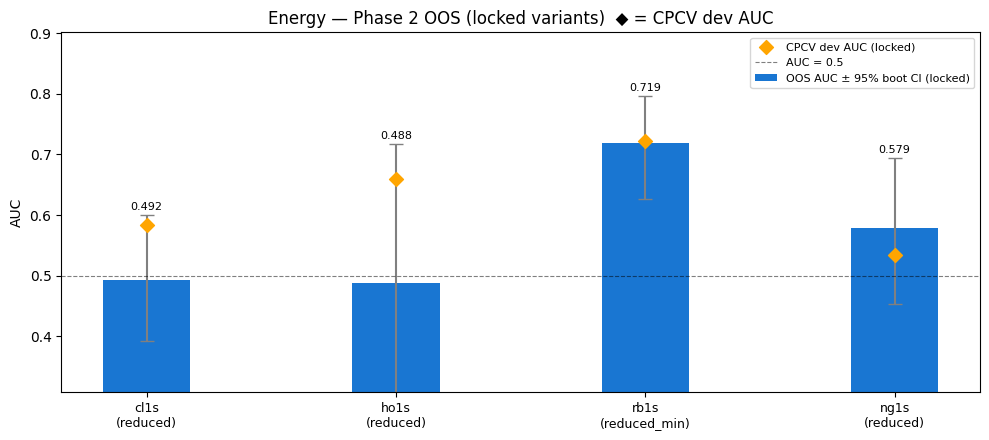

In [8]:
# ── Phase 2 summary chart ─────────────────────────────────────────────────────
oos_aucs  = []
ci_lo_abs = []
ci_hi_abs = []
dev_aucs  = []
for inst in INSTS:
    lv  = locked[inst]
    o   = oos_df[(oos_df["inst"]   == inst) & (oos_df["variant"]  == lv)].iloc[0]
    c   = cpcv_df[(cpcv_df["inst"] == inst) & (cpcv_df["variant"] == lv)].iloc[0]
    oos_aucs.append(float(o["auc"]))
    ci_lo_abs.append(float(o["auc_ci_lo"]))
    ci_hi_abs.append(float(o["auc_ci_hi"]))
    dev_aucs.append(float(c["auc_mean"]))

err_lo = [a - lo for a, lo in zip(oos_aucs, ci_lo_abs)]
err_hi = [hi - a for a, hi in zip(oos_aucs, ci_hi_abs)]
x      = np.arange(len(INSTS))
labels = [f"{i}\n({locked[i]})" for i in INSTS]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x, oos_aucs, yerr=[err_lo, err_hi], color="#1976D2",
       error_kw={"ecolor": "grey", "capsize": 5}, width=0.35,
       label="OOS AUC ± 95% boot CI (locked)")
ax.scatter(x, dev_aucs, marker="D", color="orange", zorder=5, s=50,
           label="CPCV dev AUC (locked)")
ax.axhline(0.5, color="black", linestyle="--", lw=0.8, alpha=0.5, label="AUC = 0.5")

for xi, (a, hi) in enumerate(zip(oos_aucs, err_hi)):
    if not np.isnan(a):
        ax.text(xi, a + hi + 0.005, f"{a:.3f}", ha="center", va="bottom", fontsize=8)

all_vals = [v for v in oos_aucs + dev_aucs if not np.isnan(v)]
if all_vals:
    ax.set_ylim(max(0.1, min(all_vals) - 0.18), min(1.0, max(all_vals) + 0.18))

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("AUC")
ax.set_title("Energy — Phase 2 OOS (locked variants)  ◆ = CPCV dev AUC")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


---
## Per-Instrument Detail

## cl1s — cl1s / logistic | NO SIGNAL (exploratory)

> **Selection AUC:** 0.537  lower CI 0.488 → NO SIGNAL
> **Caveat:** cl1s is treated as exploratory. OOS AUC near 0.5 is expected;
> results are shown for completeness, not for trading.

**Significant clusters from importance (used as pruned basis):**
- C2_f11_lowfreq_macro: crude stock surprise, China PMI, refinery utilisation
- C14_f12: crude/equity correlation, MRA calendar features

**Reduced variant:** PC1 of each cluster (fitted per fold on train) plus 3 raw macro features
(f11_crude_stock_surprise, f2_vol_10, f11_china_pmi_level) that did not belong to the sig clusters.


## ho1s — energy_cl_ho / MLP | NO SIGNAL (exploratory)

> **Selection AUC:** 0.492  lower CI 0.303 → NO SIGNAL (below chance)
> **Pool:** energy_cl_ho (321 rows: cl1s + ho1s). ho1s has only **34 training rows** in the pool,
> so 3/15 CPCV paths are skipped (no usable ho1s test slice). Wide confidence intervals throughout.
> **Caveat:** ho1s is shown for completeness only. Any apparent CPCV signal is noise.

**Pruned clusters (top-3 raw MDA, all non-significant):**
- C8_f11_lowfreq_macro: HY OAS, US 5Y change, US 2s10s
- C15_f11: VIX 5d change, VIX term slope, skew_z
- C1_f1: mean-reversion / momentum price features

**Reduced features:** f11_vix_term_slope, f4_pc3 (frozen F4 latent), f1_bb_bandwidth_20, f11_vix_5d_change.
`f4_pc3` is the pre-computed frozen F4 PCA component — used as-is, not re-fitted.


## rb1s — rb1s / logistic | SIGNAL (marginal, lower CI 0.51)

> **Selection AUC:** 0.577  lower CI 0.506 → SIGNAL
> **Context:** rb1s has 424 train rows and 159 test events — the largest of the energy instruments.
> No cluster is individually significant in the importance analysis.
> **Key question:** does the macro tail (dist_stock_surprise, vol_ratio) add over
> f5_signal + hy_oas alone? Compare **reduced** vs **reduced_min**.

**Pruned clusters (top-3 raw MDA, none significant):**
- F5_signal: the primary signal cluster
- C6_f11_lowfreq_macro: HY OAS, UST/Bund rates, distressed indicators
- C1_f1: mean-reversion / momentum price features

**Reduced vs reduced_min:** reduced_min = f5_signal + f11_hy_oas_5d_change only. If the
signal is essentially "read the primary signal + credit spread," reduced_min is the cleaner
implementation.


## ng1s — energy_all / MLP | SIGNAL (marginal, lower CI 0.52)

> **Selection AUC:** 0.658  lower CI 0.519 → SIGNAL
> **Pool:** energy_all (773 rows: all four energy instruments). ng1s has only **28 training rows**
> in the pool, so 3/15 CPCV paths are skipped. Results are directional; bootstrap CIs are wide.
> **Treat ng1s's signal cautiously** — the sealed OOS is the honest single read.

**Significant cluster (the only one):**
- C15_f7: OI level features (f7_oi_level, f7_oi_change, f7_oi_z_20, f2_atr_14)

**Reduced features** (proposed via RF importance heuristic, validated here on MLP):
f7_oi_change, f7_oi_level, f2_atr_14, hmm_vol_next_turbulent, hmm_vol_p2_turbulent,
hmm_vol_p0_calm. `inst_rb1s` is deliberately excluded — it is constant zero on the ng1s
pool slice and contributes no signal.

**Note:** The RF surrogate for the MLP champion was used to generate feature importance;
these reduced features are now validated on the MLP champion itself, not on the surrogate.


In [9]:
# ── Per-instrument detail ─────────────────────────────────────────────────────
for inst in INSTS:
    lv  = locked[inst]
    s   = sel.loc[inst]
    sub_cpcv = cpcv_df[cpcv_df["inst"] == inst].set_index("variant")
    sub_oos  = oos_df[oos_df["inst"] == inst].set_index("variant")
    sig = "SIGNAL" if s["signal"] else "NO SIGNAL"
    print(f"\n{'='*64}")
    print(f"{inst.upper()} | {sig} | {s['best_group']} / {s['best_model'].upper()} | locked={lv}")
    print(f"  champion AUC={s['best_auc']:.4f}  lower_ci={s['lower_ci']:.4f}  n_train={s['n_events']}")
    print()
    print("  Phase 1 CPCV:")
    for v in SIMPLICITY[inst]:
        if v not in sub_cpcv.index:
            continue
        r   = sub_cpcv.loc[v]
        tag = " ← LOCKED" if v == lv else ""
        print(f"    {v:12s}  AUC {r['auc_mean']:.4f} ± {r['auc_std']:.4f}"
              f"  logloss={fmt(r['logloss'])}  brier={fmt(r['brier'])}"
              f"  n_paths={int(r['n_paths'])}{tag}")
    print()
    print("  Phase 2 OOS:")
    for v in SIMPLICITY[inst]:
        if v not in sub_oos.index:
            continue
        r    = sub_oos.loc[v]
        role = "HEADLINE" if v == lv else "diagnostic"
        print(f"    {v:12s} [{role}]  AUC {r['auc']:.4f}"
              f"  [{r['auc_ci_lo']:.3f},{r['auc_ci_hi']:.3f}]"
              f"  logloss={fmt(r['logloss'])}  brier={fmt(r['brier'])}"
              f"  n_test={int(r['n_test'])}")
    if lv in sub_cpcv.index and lv in sub_oos.index:
        gap = float(sub_cpcv.loc[lv, "auc_mean"]) - float(sub_oos.loc[lv, "auc"])
        print(f"  Dev-OOS gap (locked): {gap:+.4f}")



CL1S | NO SIGNAL | cl1s / LOGISTIC | locked=reduced
  champion AUC=0.5374  lower_ci=0.4876  n_train=1435

  Phase 1 CPCV:
    reduced       AUC 0.5842 ± 0.0224  logloss=0.7014  brier=0.2471  n_paths=15 ← LOCKED
    pruned        AUC 0.5761 ± 0.0233  logloss=0.6830  brier=0.2451  n_paths=15
    full          AUC 0.5399 ± 0.0498  logloss=1.3803  brier=0.2811  n_paths=15

  Phase 2 OOS:
    reduced      [HEADLINE]  AUC 0.4924  [0.392,0.599]  logloss=0.6884  brier=0.2476  n_test=127
    pruned       [diagnostic]  AUC 0.5010  [0.397,0.610]  logloss=0.6878  brier=0.2473  n_test=127
    full         [diagnostic]  AUC 0.4600  [0.352,0.563]  logloss=0.7362  brier=0.2712  n_test=127
  Dev-OOS gap (locked): +0.0918

HO1S | NO SIGNAL | energy_cl_ho / MLP | locked=reduced
  champion AUC=0.4923  lower_ci=0.3031  n_train=170

  Phase 1 CPCV:
    reduced       AUC 0.6589 ± 0.1846  logloss=0.6487  brier=0.2294  n_paths=12 ← LOCKED
    pruned        AUC 0.4850 ± 0.2125  logloss=0.6677  brier=0.2387  n_

---
## Cross-Instrument Summary

In [10]:
# ── Cross-instrument summary ──────────────────────────────────────────────────
print("\n" + "=" * 76)
print("CROSS-INSTRUMENT SUMMARY")
print("=" * 76)
print(f"{'Inst':6s} {'Signal':10s} {'Locked':12s} {'Model':8s} "
      f"{'Dev AUC':>8s} {'OOS AUC':>8s} {'OOS 95% CI':^18s} {'Gap':>7s}")
print("-" * 76)
for inst in INSTS:
    lv  = locked[inst]
    s   = sel.loc[inst]
    c   = cpcv_df[(cpcv_df["inst"] == inst) & (cpcv_df["variant"] == lv)].iloc[0]
    o   = oos_df[(oos_df["inst"]   == inst) & (oos_df["variant"]  == lv)].iloc[0]
    sig = "SIGNAL" if s["signal"] else "NO SIGNAL"
    dev  = float(c["auc_mean"])
    oos  = float(o["auc"])
    ci   = f"[{float(o['auc_ci_lo']):.3f},{float(o['auc_ci_hi']):.3f}]"
    gap  = dev - oos
    mdl  = f"{s['best_group'][:8]}/{s['best_model'].upper()[:3]}"
    print(f"{inst:6s} {sig:10s} {lv:12s} {mdl:8s} {dev:8.4f} {oos:8.4f} {ci:^18s} {gap:+7.4f}")



CROSS-INSTRUMENT SUMMARY
Inst   Signal     Locked       Model     Dev AUC  OOS AUC     OOS 95% CI         Gap
----------------------------------------------------------------------------
cl1s   NO SIGNAL  reduced      cl1s/LOG   0.5842   0.4924   [0.392,0.599]    +0.0918
ho1s   NO SIGNAL  reduced      energy_c/MLP   0.6589   0.4877   [0.253,0.717]    +0.1713
rb1s   SIGNAL     reduced_min  rb1s/LOG   0.7215   0.7191   [0.626,0.796]    +0.0024
ng1s   SIGNAL     reduced      energy_a/MLP   0.5341   0.5795   [0.453,0.694]    -0.0453


---
## Caveats and Interpretation

### cl1s — NO SIGNAL confirmed
Locked (reduced) OOS AUC = 0.492. Point estimate below 0.5; CI [0.392, 0.599] straddles 0.5.
Dev-OOS gap +0.092. Consistent with NO SIGNAL in the selection table. The PCA + macro
features in the reduced variant provided no generalising signal. Exploratory run only.

### ho1s — NO SIGNAL, wide CIs, below-chance OOS
Locked (reduced) OOS AUC = 0.488. Dev-OOS gap +0.171. The large gap is expected: 12 usable
CPCV paths on a 34-row instrument slice, and only 27 test events, make both dev and OOS
estimates very noisy. CI [0.253, 0.717] is essentially uninformative. Selection table
correctly labels ho1s NO SIGNAL (lower CI 0.303). Do not draw conclusions from this run.

### rb1s — SIGNAL, near-zero dev-OOS gap
Locked (reduced_min) OOS AUC = 0.719, dev CPCV = 0.722, **gap = +0.002**.
This is the cleanest result: f5_signal + f11_hy_oas_5d_change alone delivers 0.719 OOS
with almost no overfitting penalty. The macro tail (dist_stock_surprise, vol_ratio) adds
+0.018 in CPCV but is not needed — reduced_min wins the simplicity test.
rb1s diagnostic (reduced) hits 0.738 OOS — it is shown for transparency but was not
the locked pick and cannot be used for selection.

### ng1s — SIGNAL, OOS exceeds CPCV dev
Locked (reduced) OOS AUC = 0.580, dev CPCV = 0.534, **gap = −0.046 (OOS > dev)**.
This is a favourable sign: the RF importance-heuristic feature selection (OI + HMM-vol)
generalises better on the MLP champion than its CPCV estimate suggested. The pruned
diagnostic (C15_f7 only, OOS=0.569) is close, confirming OI features drive the signal.
Full-model OOS (0.482, below chance) shows regularisation via feature reduction is essential.
Treat with caution: 28 train rows in the pool is very thin.

### Diagnostic variants
All non-locked OOS rows are **transparency diagnostics only** — they were not the locked pick
and were never used for selection. In particular, rb1s/reduced (0.738 OOS) is a diagnostic;
rb1s/reduced_min (0.719) is the headline.

### rb1s vs ng1s: structural difference
rb1s's signal (f5_signal + hy_oas) is essentially a credit-spread re-read of the primary
signal — robust and near-zero dev-OOS gap. ng1s's signal (OI + vol regime) is more
instrument-specific and fragile (thin slice, wide CPCV std), but it transfers OOS.
Both marginal signals hold; both warrant cautious position sizing.
